# Partial Information Sweep: Simulation Comparison

Compare simulation runs across information probability (π = 0 to 1) against participant judgments.

**Two DVs:**
- Cross-cultural moral judgments (Logan, N=2,059, 20 countries)
- Universalizability judgments (Joe, US, N=43)

**Two metrics:**
- β(U_AW): coefficient on universalized aggregate welfare in the full regression
- ΔR²: additional variance explained by adding U_AW to outcome-only model

**Four reference baselines:**
- Blind, no prediction (random_blind, L0)
- Blind, 1-step prediction (random_blind_L1)
- joe (fixed order, full info)
- Full information, random order (random)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from build_utils import (
    get_experimental_data, get_outcome_metrics,
    get_universalization_summary, build_design_matrix,
)
from comparison_utils import (
    evaluate_runs, compute_simulation_noise,
    plot_two_panel, plot_single_panel, plot_comparison_table,
)

%matplotlib inline
Path("figures").mkdir(exist_ok=True)


## 1. Define runs and load data

In [2]:
# ── Participant data ──
XP_FILE = "country_agg_judgment.csv"
COUNTRY = None  # pool all countries

xp = get_experimental_data(XP_FILE)
out = get_outcome_metrics(recompute=False)

# ── Joe's US data ──
joe = pd.read_csv("../data/experimental/joe_agg_univ_and_moral_judgments.csv")

# ── Info probability sweep ──
RUNS_INFO_SWEEP = {
    "00full":  "0full_03-04",
    "001full": "001full_03-14",
    "005full": "005full_03-14",
    "01full":  "01full_03-14",
    "02full":  "02full_03-14",
    "05full":  "05full_03-13",
    "10full":  "10full_03-04",
    "20full":  "20full_03-04",
    "30full":  "30full_03-04",
    "40full":  "40full_03-04",
    "50full":  "50full_03-13",
    "60full":  "60full_03-04",
    "70full":  "70full_03-04",
    "80full":  "80full_03-04",
    "90full":  "90full_03-04",
    "100full": "100full_03-15",
}

# Infer info_prob from tag names
INFO_PROBS = {tag: float("0." + tag.replace("full", "")) for tag in RUNS_INFO_SWEEP}

# Reference baselines
RUNS_BASELINES = {
    "random_blind":    "blind_L0_random_02-06",
    "random_blind_L1": "blind_l1_random_02-06",
    "random":          "full_random_02-06",
    "joe":             "joe_1_02-06",
}

ALL_RUNS = {**RUNS_INFO_SWEEP, **RUNS_BASELINES}


## 2. Build design matrices

In [3]:
design_mats = {}
univ_summaries = {}

for tag, run_label in ALL_RUNS.items():
    try:
        univ = get_universalization_summary(run_label, recompute=False)
        univ_summaries[tag] = univ
        design = build_design_matrix(univ, out, xp, country=COUNTRY)
        design_mats[tag] = design
    except Exception as e:
        print(f"  Warning: {tag} ({run_label}): {e}")

print(f"Loaded {len(design_mats)} runs")

# Also build design matrices with Joe's DV merged in
dm_joe = {}
for tag, dm in design_mats.items():
    merged = dm.copy()
    merged["_merge_key"] = merged["stimulus"].str.replace(r"_(1cut|bad|badder)$", "", regex=True)
    joe_renamed = joe.rename(columns={"stimulus": "_merge_key"})
    merged = merged.merge(
        joe_renamed[["_merge_key", "univ_judgment_mean", "moral_judgment_mean"]],
        on="_merge_key", how="left"
    )
    merged = merged.drop(columns=["_merge_key"])
    dm_joe[tag] = merged

Loaded 20 runs


## 3. Evaluate all runs

In [4]:
# ── DV 1: Logan cross-cultural moral judgments ──
eval_logan = evaluate_runs(design_mats)
eval_logan["info_prob"] = eval_logan["tag"].map(INFO_PROBS)

print("=== DV: Cross-cultural moral judgments (N=2,059) ===")
display(plot_comparison_table(eval_logan, 
    cols=["tag", "info_prob", "r_U_AW", "beta_U_AW", "se_U_AW", "p_U_AW", "delta_R2", "delta_BIC"]))


=== DV: Cross-cultural moral judgments (N=2,059) ===


,tag,info_prob,r_U_AW,beta_U_AW,se_U_AW,p_U_AW,delta_R2,delta_BIC
0,40full,0.400,0.6116,0.1098,0.0361,0.0045,0.0804,-5.7481
1,random_blind_L1,NaN,0.5890,0.1100,0.0364,0.0048,0.0792,-5.5907
2,50full,0.500,0.5950,0.1081,0.0374,0.0067,0.0739,-4.9057
3,joe,NaN,0.5470,0.1022,0.0354,0.0067,0.0739,-4.9050
4,70full,0.700,0.6051,0.1117,0.0390,0.0072,0.0727,-4.7489
5,90full,0.900,0.5768,0.1052,0.0370,0.0074,0.0721,-4.6735
6,random,NaN,0.5957,0.1057,0.0373,0.0077,0.0715,-4.5944
7,20full,0.200,0.5946,0.1044,0.0369,0.0078,0.0714,-4.5804
8,30full,0.300,0.5862,0.1054,0.0373,0.0079,0.0712,-4.5570
9,05full,0.050,0.5715,0.1020,0.0365,0.0084,0.0701,-4.4089


In [5]:
# ── DV 2: Joe's universalizability judgments ──
eval_joe = evaluate_runs(dm_joe, dv_col="univ_judgment_mean")
eval_joe["info_prob"] = eval_joe["tag"].map(INFO_PROBS)


print("=== DV: Universalizability judgments (US, N=43) ===")
display(plot_comparison_table(eval_joe,
    cols=["tag", "info_prob", "r_U_AW", "beta_U_AW", "se_U_AW", "p_U_AW", "delta_R2"]))




=== DV: Universalizability judgments (US, N=43) ===


,tag,info_prob,r_U_AW,beta_U_AW,se_U_AW,p_U_AW,delta_R2
0,40full,0.400,0.8521,6.2228,1.4562,0.0027,0.5015
1,100full,0.100,0.8582,5.9409,1.3937,0.0028,0.5007
2,90full,0.900,0.8496,6.1085,1.4862,0.0034,0.4894
3,05full,0.050,0.8286,6.4326,1.5971,0.0038,0.4830
4,10full,0.100,0.8284,6.6041,1.6743,0.0043,0.4763
5,20full,0.200,0.8262,6.0717,1.5816,0.0050,0.4675
6,joe,NaN,0.8334,5.7231,1.4973,0.0051,0.4660
7,70full,0.700,0.8214,6.2737,1.6577,0.0054,0.4628
8,30full,0.300,0.8145,6.2031,1.6540,0.0056,0.4597
9,random,NaN,0.8218,5.8932,1.5752,0.0057,0.4589


## 4. Main figures

### β(U_AW) across information conditions


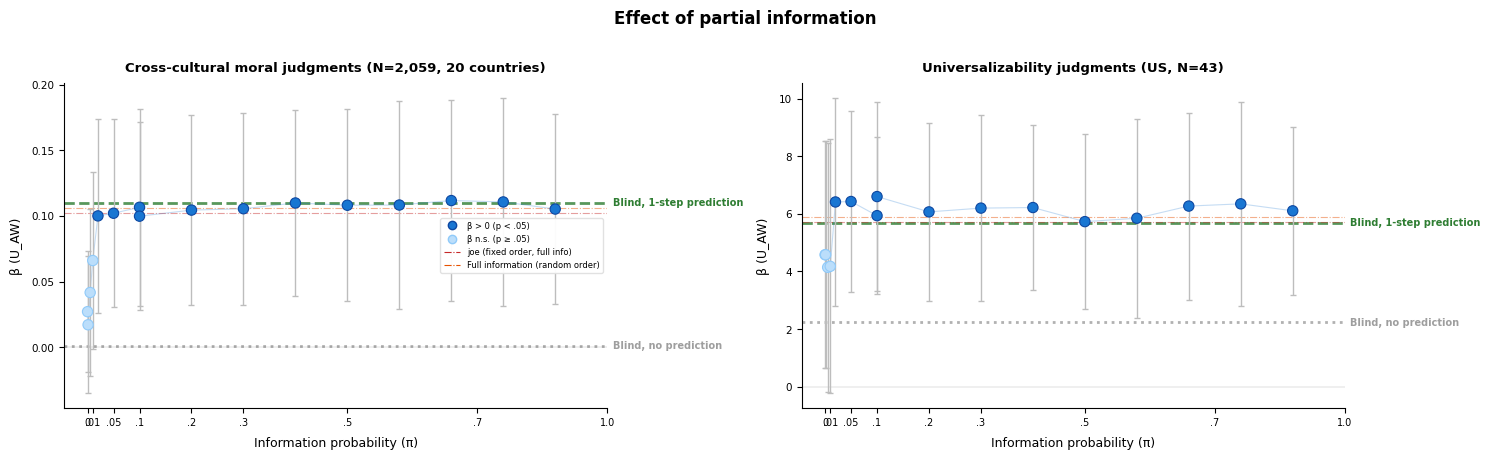

In [6]:
# Beta, linear scale
fig, _ = plot_two_panel(
    eval_logan, eval_joe,
    metric="beta",
    title_left="Cross-cultural moral judgments (N=2,059, 20 countries)",
    title_right="Universalizability judgments (US, N=43)",
    suptitle="Effect of partial information",
    save_path="figures/fig_beta_linear.png",
)
plt.show()


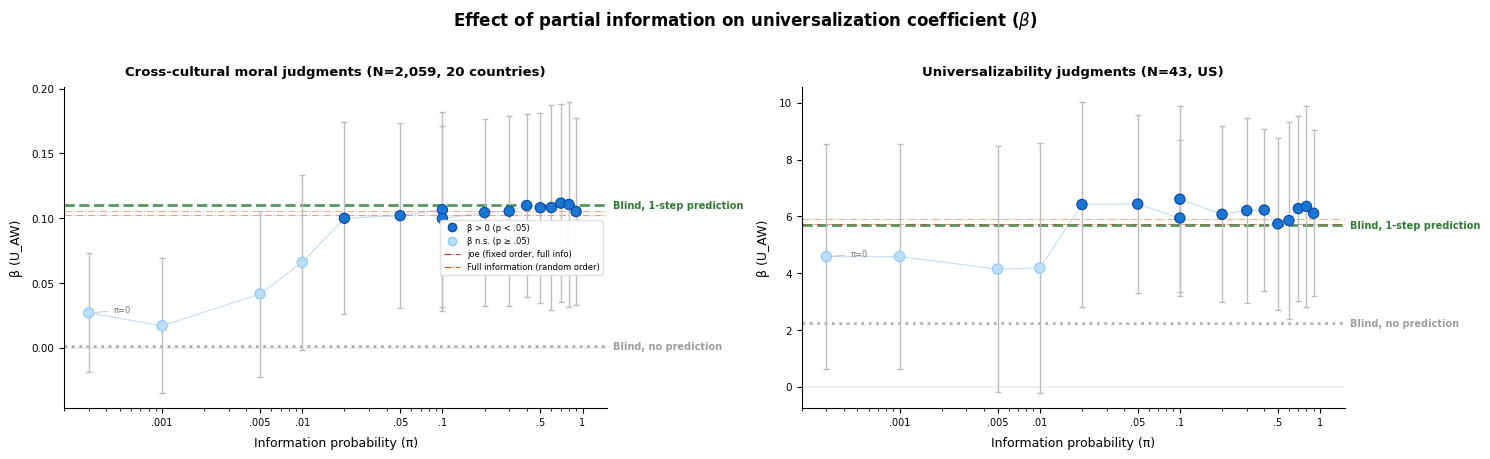

In [7]:
# Beta, log scale
fig, _ = plot_two_panel(
    eval_logan, eval_joe,
    metric="beta",
    title_left="Cross-cultural moral judgments (N=2,059, 20 countries)",
    title_right="Universalizability judgments (N=43, US)",
    suptitle=r"Effect of partial information on universalization coefficient ($\beta$)",
    logscale=True,
    save_path="figures/fig_beta_log.png",
)
plt.show()


### ΔR² across information conditions

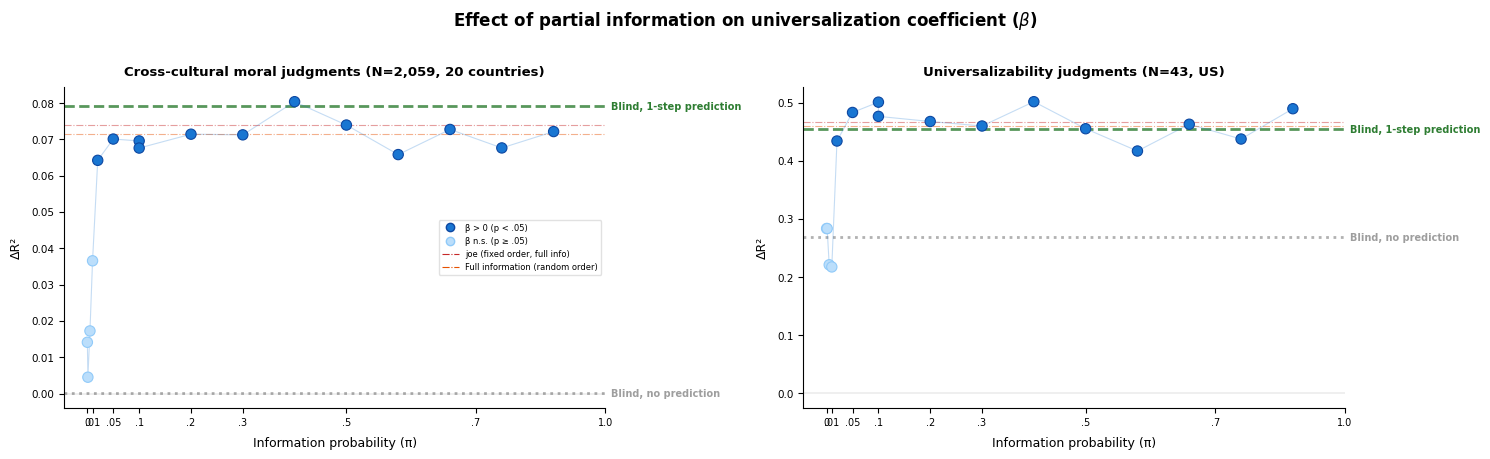

In [8]:
# Delta R2, linear scale
fig, _ = plot_two_panel(
    eval_logan, eval_joe,
    metric="dr2",
    title_left="Cross-cultural moral judgments (N=2,059, 20 countries)",
    title_right="Universalizability judgments (N=43, US)",
    suptitle=r"Effect of partial information on universalization coefficient ($\beta$)",
    save_path="figures/fig_dr2_linear.png",
)
plt.show()


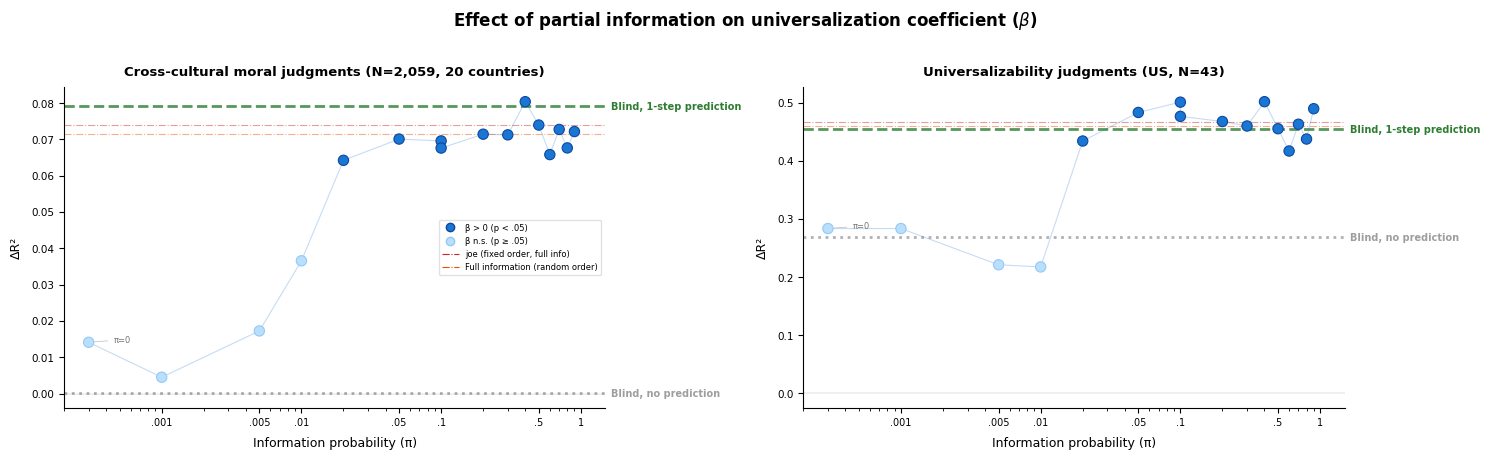

In [9]:
# Delta R2, log scale
fig, _ = plot_two_panel(
    eval_logan, eval_joe,
    metric="dr2",
    title_left="Cross-cultural moral judgments (N=2,059, 20 countries)",
    title_right="Universalizability judgments (US, N=43)",
    suptitle=r"Effect of partial information on universalization coefficient ($\beta$)",
    logscale=True,
    save_path="figures/fig_dr2_log.png",
)
plt.show()


## 5. Simulation noise

In [10]:
noise_df = compute_simulation_noise(univ_summaries)
display(noise_df.round(4))


,tag,n_maps,univ_aggregate_welfare_avg_sd,univ_aggregate_welfare_grand_mean,univ_aggregate_welfare_cv,prop_finished_mean
0,00full,28,2.5304,-3.0152,0.8392,0.9929
1,001full,28,2.7414,-3.1996,0.8568,0.9982
2,005full,28,1.7524,-2.4920,0.7032,1.0000
3,01full,28,1.3567,-2.2036,0.6157,1.0000
4,02full,28,0.7042,-1.8323,0.3843,1.0000
5,05full,28,0.5824,-1.6664,0.3495,1.0000
6,10full,28,0.5449,-1.5201,0.3585,1.0000
7,20full,28,0.4810,-1.4209,0.3385,1.0000
8,30full,28,0.4261,-1.3191,0.3230,1.0000
9,40full,28,0.4591,-1.3041,0.3520,1.0000
